(12)=
# Chapter 12: Polynomial Fitting & Interpolation

**Topics Covered:**
- Polynomial basics: `np.poly1d`, `np.polyval`, `np.polyfit`
- Least-squares polynomial fitting: choosing the right degree, residuals, $R^2$
- Taylor series: definition, convergence, and ChE linearization
- Polynomial interpolation: Lagrange method and Runge's phenomenon
- Spline interpolation: `CubicSpline`, `interp1d`, and steam table application

In [31]:
# ── All imports ─────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

(12.1)=
## 12.1 Motivation: Heat Capacity of CO$_2$

In chemical engineering, we frequently need $C_p(T)$ — the molar heat capacity as a function of temperature — to compute:

$$
Q = n \int_{T_1}^{T_2} C_p(T)\, dT
$$

NIST publishes $C_p$ in tabulated form at discrete temperatures. Before we can integrate, we need a **continuous mathematical model** — a polynomial — that passes smoothly through the data.

Below is a subset of NIST data for CO$_2$ (ideal gas, J mol$^{-1}$ K$^{-1}$):

| $T$ (K) | $C_p$ (J mol$^{-1}$ K$^{-1}$) |
|---------|-------------------------------|
| 300     | 37.13                         |
| 400     | 41.33                         |
| 500     | 44.60                         |
| 600     | 47.33                         |
| 700     | 49.65                         |
| 800     | 51.61                         |
| 900     | 53.26                         |
| 1000    | 54.31                         |
| 1100    | 55.37                         |
| 1200    | 56.21                         |

We want to fit $C_p(T) \approx a_0 + a_1 T + a_2 T^2 + \cdots$ so we can evaluate it at any temperature and integrate it analytically.

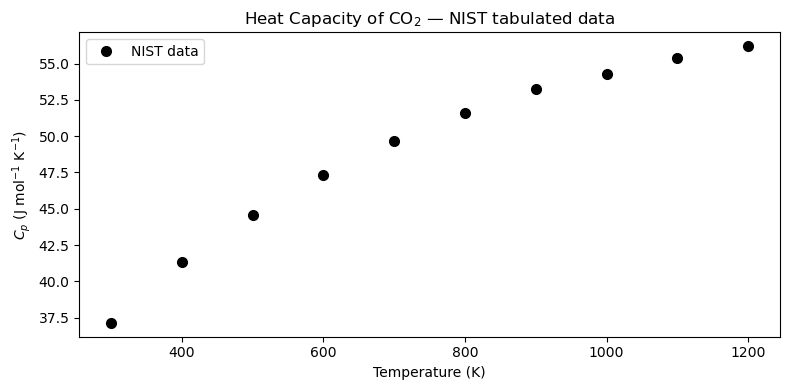

In [5]:
# NIST tabulated Cp data for CO2 (ideal gas)
T_data  = np.array([300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200], dtype=float)  # K
Cp_data = np.array([37.13, 41.33, 44.60, 47.33, 49.65,
                    51.61, 53.26, 54.31, 55.37, 56.21])  # J/(mol K)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(T_data, Cp_data, 'ko', markersize=7, label='NIST data')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel(r'$C_p$ (J mol$^{-1}$ K$^{-1}$)')
ax.set_title(r'Heat Capacity of CO$_2$ — NIST tabulated data')
ax.legend()
plt.tight_layout()
plt.show()

(12.2)=
## 12.2 Polynomial Basics

A degree-$n$ polynomial is:

$$
p(x) = a_n x^n + a_{n-1} x^{n-1} + \cdots + a_1 x + a_0
$$

NumPy stores polynomial coefficients in **descending order** (highest power first). Three key tools:

| Function | Purpose |
|----------|---------|
| `np.poly1d(coeffs)` | Create a callable polynomial object |
| `np.polyval(coeffs, x)` | Evaluate polynomial at $x$ |
| `np.polyfit(x, y, deg)` | Least-squares fit: returns coefficients |

**Convention:** `coeffs = [a_n, a_{n-1}, ..., a_1, a_0]` — highest power first.

---

### The coefficient array

Say you have $p(x) = 3x^2 + 5x - 2$. NumPy represents this as `[3, 5, -2]`:

```
index:  0    1    2
value: [3,   5,  -2]
         ↑    ↑    ↑
        x²   x¹   x⁰
```

### `np.poly1d(coeffs)` — callable polynomial object

Wraps the coefficient list into an object you can call like a function:
```python
p = np.poly1d([3, 5, -2])
p(1)   # → 3(1)² + 5(1) - 2 = 6
p(0)   # → -2
```
Bonus methods: `p.deriv()` (derivative), `p.integ()` (integral), `p.roots` (zeros).

### `np.polyval(coeffs, x)` — evaluate from the list directly

Same result, no object needed. Works on scalars or arrays:
```python
np.polyval([3, 5, -2], 1)           # → 6
np.polyval([3, 5, -2], [0, 1, 2])   # → [-2, 6, 20]
```
Use this when you only need values and don't need derivatives/integrals.

### `np.polyfit(x, y, deg)` — find best-fit coefficients

Given data points, returns a coefficient array in the same descending convention:
```python
coeffs = np.polyfit(x_data, y_data, deg=3)  # fit  → coeffs
p      = np.poly1d(coeffs)                  # wrap → callable
y_fit  = p(x_fine)                          # evaluate on dense grid
# or equivalently:
y_fit  = np.polyval(coeffs, x_fine)
```

Use `poly1d` when you also need `.deriv()` / `.integ()` / `.roots`; use `polyval` when you just need numbers.

In [6]:
# ── Coefficient convention demo ───────────────────────────────────────────
# p(x) = 3x² + 5x - 2   →   coeffs = [3, 5, -2]  (descending order)
coeffs_demo = [3, 5, -2]

p_demo = np.poly1d(coeffs_demo)
print("poly1d pretty-print:")
print(p_demo)

# Evaluate at a few points
xs = [0, 1, 2]
print("\nx   poly1d   polyval   manual")
for x in xs:
    manual = 3*x**2 + 5*x - 2
    print(f"{x}   {p_demo(x):6.1f}   {np.polyval(coeffs_demo, x):6.1f}   {manual:6.1f}")

# polyval works on arrays too
print("\npolyval on array [0,1,2]:", np.polyval(coeffs_demo, xs))

# Derivative and integral via poly1d
print("\nDerivative p'(x):")
print(p_demo.deriv())
print("Indefinite integral ∫p dx (+ C):")
print(p_demo.integ())
print("Roots (p(x)=0):", p_demo.roots.round(4))


poly1d pretty-print:
   2
3 x + 5 x - 2

x   poly1d   polyval   manual
0     -2.0     -2.0     -2.0
1      6.0      6.0      6.0
2     20.0     20.0     20.0

polyval on array [0,1,2]: [-2  6 20]

Derivative p'(x):
 
6 x + 5
Indefinite integral ∫p dx (+ C):
   3       2
1 x + 2.5 x - 2 x
Roots (p(x)=0): [-2.      0.3333]


In [7]:
# Define p(x) = 2x^3 - 3x^2 + x - 5  (coefficients in descending order)
coeffs = [2, -3, 1, -5]

p = np.poly1d(coeffs)
print("Polynomial p(x):")
print(p)

# Evaluate at x = 2
x_val = 2.0
print(f"\np({x_val}) using poly1d  : {p(x_val):.4f}")
print(f"p({x_val}) using polyval : {np.polyval(coeffs, x_val):.4f}")
# Manual: 2(8) - 3(4) + 1(2) - 5 = 16 - 12 + 2 - 5 = 1
print(f"Manual check          : {2*x_val**3 - 3*x_val**2 + 1*x_val - 5:.4f}")

Polynomial p(x):
   3     2
2 x - 3 x + 1 x - 5

p(2.0) using poly1d  : 1.0000
p(2.0) using polyval : 1.0000
Manual check          : 1.0000


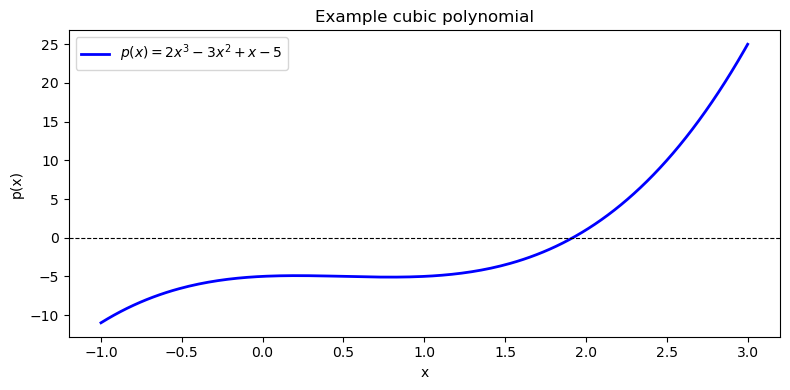

In [8]:
# Plot the polynomial over [-1, 3]
x = np.linspace(-1, 3, 200)
y = np.polyval(coeffs, x)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, 'b-', linewidth=2, label=r'$p(x) = 2x^3 - 3x^2 + x - 5$')
ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.set_title('Example cubic polynomial')
ax.legend()
plt.tight_layout()
plt.show()

(12.3)=
## 12.3 Least-Squares Polynomial Fitting

**`np.polyfit(x, y, deg)`** finds the degree-`deg` polynomial coefficients that minimize the sum of squared residuals:

$$
\min_{a_0, \ldots, a_n} \sum_{i=1}^{N} \left[ y_i - p(x_i) \right]^2
$$

This is ordinary least squares applied to a polynomial basis. The function returns coefficients in descending order (highest power first), just like `np.poly1d` expects.

(12.3.1)=
### 12.3.1 Fitting Cp(T) with Different Degrees

We fit the CO$_2$ data with degree 1, 2, and 3 polynomials and compare the results visually.

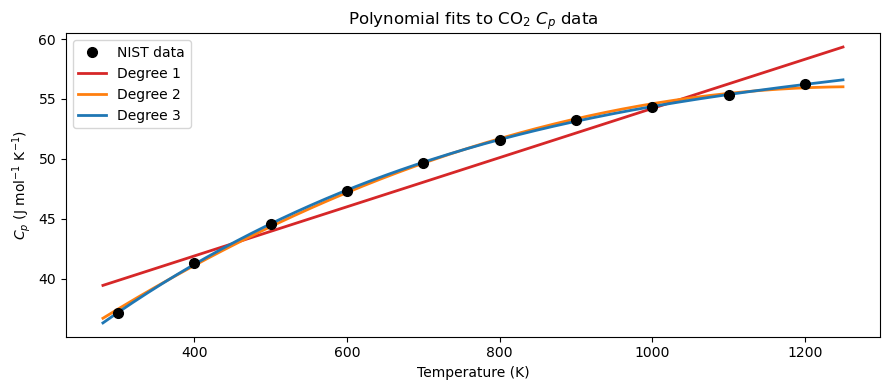

In [9]:
# ── Fit Cp(T) with degree 1, 2, 3 polynomials ────────────────────────────────
T_fine  = np.linspace(280, 1250, 300)
degrees = [1, 2, 3]
colors  = ['tab:red', 'tab:orange', 'tab:blue']
fits    = {}    # store coefficient arrays keyed by degree

for deg in degrees:
    fits[deg] = np.polyfit(T_data, Cp_data, deg)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(T_data, Cp_data, 'ko', markersize=7, zorder=5, label='NIST data')
for deg, color in zip(degrees, colors):
    ax.plot(T_fine, np.polyval(fits[deg], T_fine),
            color=color, linewidth=2, label=f'Degree {deg}')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel(r'$C_p$ (J mol$^{-1}$ K$^{-1}$)')
ax.set_title(r'Polynomial fits to CO$_2$ $C_p$ data')
ax.legend()
plt.tight_layout()
plt.show()

The residual $e_i$ is the vertical distance between a measured data point and the model's prediction at that same $x$:

$$
e_i = y_i - p(x_i)
$$

A positive residual means the model underpredicts; negative means it overpredicts. A good fit has residuals that are small and scattered randomly around zero.

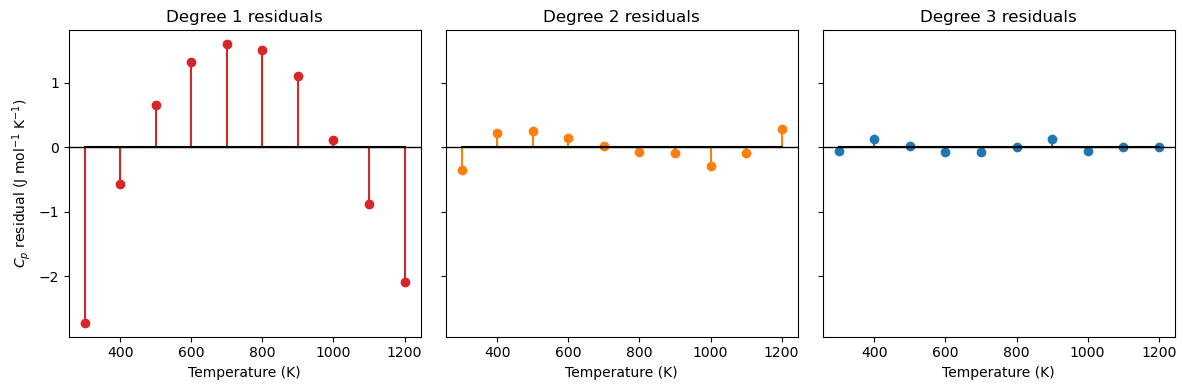

In [13]:
# ── Residual stem plots for each degree ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, deg, color in zip(axes, degrees, colors):
    Cp_pred   = np.polyval(fits[deg], T_data)
    residuals = Cp_data - Cp_pred
    ax.stem(T_data, residuals, linefmt=color, markerfmt='o', basefmt='k-')
    ax.axhline(0, color='k', linewidth=1)
    ax.set_xlabel('Temperature (K)')
    ax.set_title(f'Degree {deg} residuals')

axes[0].set_ylabel(r'$C_p$ residual (J mol$^{-1}$ K$^{-1}$)')
plt.tight_layout()
plt.show()

(12.3.2)=
### 12.3.2 Fit Quality Metrics: MAE, MSE, and $R^2$

Given residuals $e_i = y_i - p(x_i)$, where:
- $y_i$ — observed (measured) value at point $i$
- $p(x_i)$ — model-predicted value at the same point $x_i$

three standard metrics quantify how well the model fits the data:

$$
\text{MAE} = \frac{1}{N}\sum_{i=1}^{N} |e_i|
\qquad
\text{MSE} = \frac{1}{N}\sum_{i=1}^{N} e_i^2
\qquad
R^2 = 1 - \frac{\sum_i e_i^2}{\sum_i (y_i - \bar{y})^2}
$$

| Metric | Full name | Units | Interpretation |
|--------|-----------|-------|----------------|
| **MAE** | Mean Absolute Error | same as $y$ | Average magnitude of error; easy to interpret |
| **MSE** | Mean Squared Error | $y^2$ | Penalizes large errors more heavily; used by least-squares optimization |
| **$R^2$** | Coefficient of Determination | dimensionless | Fraction of variance explained by the model; 1 = perfect |

**Why square in MSE (and not just use MAE)?**
- **Penalize large errors more heavily** — an error of 2 contributes 4× more than an error of 1; the fit is driven by the worst offenders
- **Smooth, differentiable objective** — $e_i^2$ has a clean derivative everywhere, which is what allows least-squares to be solved analytically; $|e_i|$ is not differentiable at zero

**Interpreting $R^2$:** The denominator $\sum_i(y_i - \bar{y})^2$ is the total variance in the data (how spread out the measurements are). The numerator $\sum_i e_i^2$ is the variance the model *failed* to explain. Subtracting their ratio from 1 gives the fraction the model *does* explain.

- $R^2 = 1$ — perfect fit; every residual is zero
- $R^2 = 0$ — the model does no better than just predicting $\bar{y}$ for every point
- $R^2 < 0$ — the model is worse than the mean (a sign something is seriously wrong)

In [10]:
import numpy as np
# ── MAE, MSE, R² for each polynomial degree ──────────────────────────────────
SS_tot = np.sum((Cp_data - np.mean(Cp_data))**2)

print(f"{'Degree':>6}  {'MAE':>18}  {'MSE':>18}  {'R²':>10}")
print(f"{'':>6}  {'(J/mol/K)':>18}  {'(J/mol/K)²':>18}  {'':>10}")
print("-" * 60)
for deg in degrees:
    Cp_pred   = np.polyval(fits[deg], T_data)
    residuals = Cp_data - Cp_pred
    MAE = np.mean(np.abs(residuals))
    MSE = np.mean(residuals**2)
    R2  = 1.0 - np.sum(residuals**2) / SS_tot
    print(f"{deg:>6}  {MAE:>18.6f}  {MSE:>18.6f}  {R2:>10.6f}")

Degree                 MAE                 MSE          R²
                 (J/mol/K)          (J/mol/K)²            
------------------------------------------------------------
     1            1.256000            2.114124    0.942543
     2            0.179212            0.043519    0.998817
     3            0.052923            0.004851    0.999868


(12.3.3)=
### 12.3.3 MAE vs $R^2$: They Can Disagree

MAE and $R^2$ measure different things, so a model can score well on one and poorly on the other.

**Case A — Low MAE, low $R^2$:**
All errors are small in absolute magnitude, but the data has almost no variance. The model barely outperforms the flat mean, so $R^2$ stays near zero even though MAE looks fine.

**Case B — High MAE, high $R^2$:**
The data has a huge range (high variance). Errors are large in absolute units, giving a high MAE — but the model tracks the trend so well that $R^2$ is still close to 1.

The takeaway: **always report both**. MAE tells you the error in physical units (is it acceptable for your application?); $R^2$ tells you whether the model captures the structure of the data.

Case A — Low MAE, Low R²
  Data range : 9.952 – 10.046  (spread ≈ 0.094)
  MAE = 0.0918    MSE = 0.009197    R² = -11.0804

Case B — High MAE, High R²
  Data range : 47.9 – 10018.2  (spread ≈ 9970.3)
  MAE = 21.6016    MSE = 721.01    R² = 0.9999


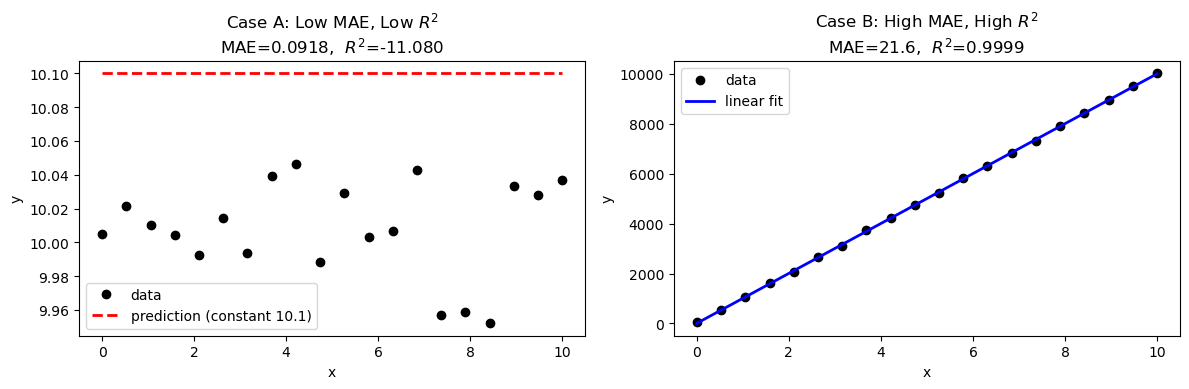

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def metrics(y, y_pred):
    e    = y - y_pred
    mae  = np.mean(np.abs(e))
    mse  = np.mean(e**2)
    ss_res = np.sum(e**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2   = 1 - ss_res / ss_tot
    return mae, mse, r2

# ── Case A: Low MAE, Low R² ───────────────────────────────────────────────────
# Data clusters tightly around 10.0 (very low variance).
# The model predicts a constant 10.1 — errors are tiny, but so is the spread,
# so R² is low because the model barely beats the mean.
np.random.seed(0)
x_A  = np.linspace(0, 10, 20)
y_A  = 10.0 + np.random.uniform(-0.05, 0.05, 20)   # near-flat data, range ≈ 0.1
yp_A = np.full_like(y_A, 10.1)                     # constant prediction slightly off

mae_A, mse_A, r2_A = metrics(y_A, yp_A)
print("Case A — Low MAE, Low R²")
print(f"  Data range : {y_A.min():.3f} – {y_A.max():.3f}  (spread ≈ {y_A.max()-y_A.min():.3f})")
print(f"  MAE = {mae_A:.4f}    MSE = {mse_A:.6f}    R² = {r2_A:.4f}")

# ── Case B: High MAE, High R² ─────────────────────────────────────────────────
# Data spans 0–10 000 (huge variance) with a clean linear trend.
# A linear fit tracks it perfectly (R² ≈ 1), but residuals are ~50 units → high MAE.
x_B  = np.linspace(0, 10, 20)
y_B  = 1000 * x_B + np.random.uniform(-50, 50, 20)   # large range, noisy
coeffs_B = np.polyfit(x_B, y_B, 1)
yp_B = np.polyval(coeffs_B, x_B)

mae_B, mse_B, r2_B = metrics(y_B, yp_B)
print("\nCase B — High MAE, High R²")
print(f"  Data range : {y_B.min():.1f} – {y_B.max():.1f}  (spread ≈ {y_B.max()-y_B.min():.1f})")
print(f"  MAE = {mae_B:.4f}    MSE = {mse_B:.2f}    R² = {r2_B:.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(x_A, y_A,  'ko', markersize=6, label='data')
ax.plot(x_A, yp_A, 'r--', linewidth=2, label='prediction (constant 10.1)')
ax.set_title(f'Case A: Low MAE, Low $R^2$\nMAE={mae_A:.4f},  $R^2$={r2_A:.3f}')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend()

ax = axes[1]
ax.plot(x_B, y_B,  'ko', markersize=6, label='data')
ax.plot(x_B, yp_B, 'b-', linewidth=2, label='linear fit')
ax.set_title(f'Case B: High MAE, High $R^2$\nMAE={mae_B:.1f},  $R^2$={r2_B:.4f}')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend()

plt.tight_layout()
plt.show()

(12.3.4)=
### 12.3.4 Overfitting: When Higher Degree Hurts

Adding more polynomial terms always reduces training error, but can create **overfitting**: the polynomial wiggles between data points and performs poorly outside the training range.

**Why does adding terms always reduce training error?**
With $N$ data points and a degree-$(N-1)$ polynomial, you have exactly enough free coefficients to pass through every point perfectly — residuals become zero by construction. But this is not a good model; it has memorized the noise in the data rather than learned the underlying trend.

**Degrees of freedom** = number of adjustable parameters (coefficients) available to fit the data. A degree-$n$ polynomial has $n+1$ coefficients, so $n+1$ degrees of freedom.

| Degree | Degrees of freedom | Behavior |
|--------|--------------------|----------|
| High ($N-1$) | $N$ — one per data point | Zero training error · High variance · Overfitting risk |
| Low–moderate | $\ll N$ | Nonzero residual · Better generalization · Controlled flexibility |

**The bias-variance tradeoff:**
- A low-degree polynomial is *too rigid* — it misses real structure in the data
- A high-degree polynomial is *too flexible* — it chases every fluctuation and noise spike

The right degree sits in between: flexible enough to capture the physical trend, not so flexible that it fits the noise. A practical warning sign: if the polynomial behaves wildly *between* data points or shoots off just outside the data range, the degree is too high.

$$
\text{If } \deg(p) = N - 1 \text{ and you have } N \text{ points} \implies \text{SS}_{\text{res}} = 0,\quad R^2 = 1 \quad \text{(but the model is useless)}
$$

Here we deliberately use degree 9 (with only 10 data points) to illustrate the problem.

Degree         MAE        R²  Note
------------------------------------------------
     2      0.6030    0.1219  underfit — misses oscillations
     5      0.2763    0.7914  good fit — captures structure
     9      0.1583    0.9236  starts to overfit noise


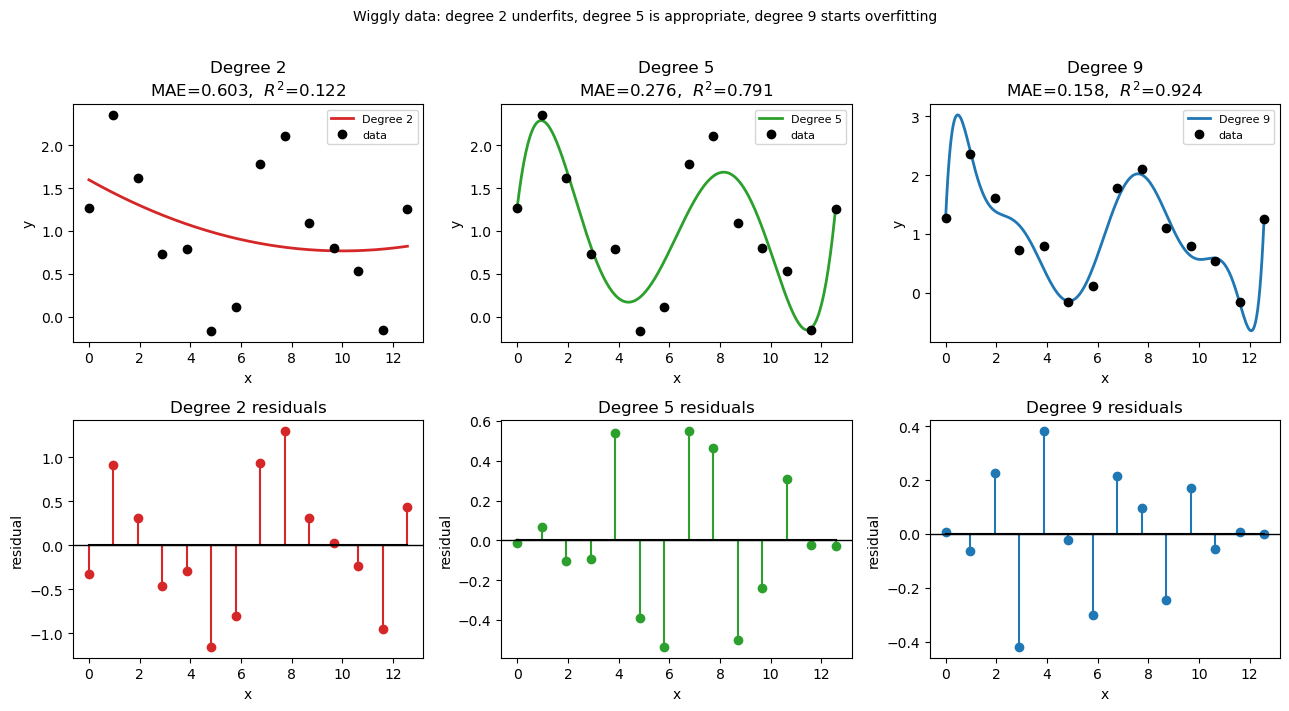

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# ── Wiggly dataset: a signal with genuine oscillations + small noise ──────────
# Imagine a periodic reaction yield measured across 12 experimental conditions.
np.random.seed(3)
x_wig = np.linspace(0, 4 * np.pi, 14)
y_wig = np.sin(x_wig) + 0.5 * np.sin(2 * x_wig) + np.random.normal(1, 0.15, 14) # np.sin(x_wig) + 0.5 * np.sin(2 * x_wig) + 


x_fine = np.linspace(0, 4 * np.pi, 300)

# Fit with degree 2, 5, and 9
degs   = [2, 5, 9]
colors = ['tab:red', 'tab:green', 'tab:blue']
fits_w = {d: np.polyfit(x_wig, y_wig, d) for d in degs}

# ── Metrics ───────────────────────────────────────────────────────────────────
SS_tot_w = np.sum((y_wig - np.mean(y_wig))**2)
print(f"{'Degree':>6}  {'MAE':>10}  {'R²':>8}  {'Note'}")
print("-" * 48)
notes = {2: 'underfit — misses oscillations',
         5: 'good fit — captures structure',
         9: 'starts to overfit noise'}
for d in degs:
    pred = np.polyval(fits_w[d], x_wig)
    res  = y_wig - pred
    mae  = np.mean(np.abs(res))
    r2   = 1 - np.sum(res**2) / SS_tot_w
    print(f"{d:>6}  {mae:>10.4f}  {r2:>8.4f}  {notes[d]}")

# ── Plot: fits ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for col, (d, color) in enumerate(zip(degs, colors)):
    y_pred_fine = np.polyval(fits_w[d], x_fine)
    y_pred_data = np.polyval(fits_w[d], x_wig)
    residuals   = y_wig - y_pred_data
    mae  = np.mean(np.abs(residuals))
    r2   = 1 - np.sum(residuals**2) / SS_tot_w

    # Top row: fit vs data
    ax = axes[0, col]
    ax.plot(x_fine, y_pred_fine, color=color, linewidth=2, label=f'Degree {d}')
    ax.plot(x_wig, y_wig, 'ko', markersize=6, zorder=5, label='data')
    ax.set_title(f'Degree {d}\nMAE={mae:.3f},  $R^2$={r2:.3f}')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=8)

    # Bottom row: residuals
    ax = axes[1, col]
    ax.stem(x_wig, residuals, linefmt=color, markerfmt='o', basefmt='k-')
    ax.axhline(0, color='k', linewidth=1)
    ax.set_title(f'Degree {d} residuals')
    ax.set_xlabel('x'); ax.set_ylabel('residual')

plt.suptitle('Wiggly data: degree 2 underfits, degree 5 is appropriate, degree 9 starts overfitting',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

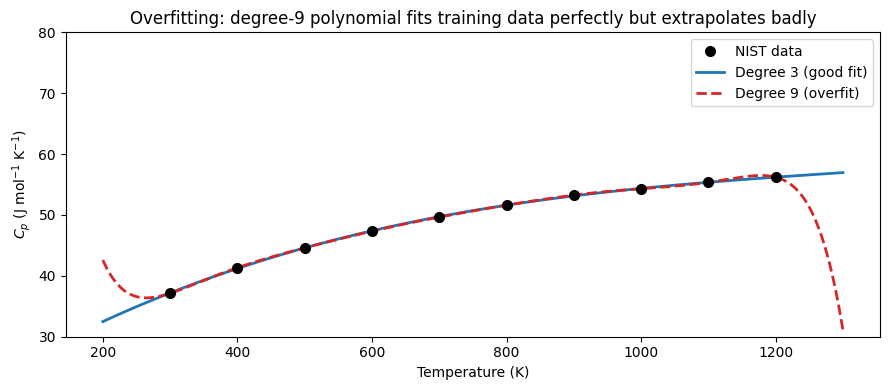

Lesson: For smooth physical data, a low-degree polynomial (2-4) is usually best.
Use R² and visual inspection — not just training error — to choose degree.


In [9]:
# ── Overfitting demonstration ─────────────────────────────────────────────────
coeffs_deg3 = np.polyfit(T_data, Cp_data, 3)
coeffs_deg9 = np.polyfit(T_data, Cp_data, 9)

T_ext = np.linspace(200, 1300, 400)   # extend beyond the data range

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(T_data, Cp_data, 'ko', markersize=7, zorder=5, label='NIST data')
ax.plot(T_ext, np.polyval(coeffs_deg3, T_ext),
        'tab:blue', linewidth=2, label='Degree 3 (good fit)')
ax.plot(T_ext, np.polyval(coeffs_deg9, T_ext),
        'tab:red',  linewidth=2, linestyle='--', label='Degree 9 (overfit)')
ax.set_ylim(30, 80)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel(r'$C_p$ (J mol$^{-1}$ K$^{-1}$)')
ax.set_title('Overfitting: degree-9 polynomial fits training data perfectly but extrapolates badly')
ax.legend()
plt.tight_layout()
plt.show()

print("Lesson: For smooth physical data, a low-degree polynomial (2-4) is usually best.")
print("Use R² and visual inspection — not just training error — to choose degree.")

(12.3.5)=
### 12.3.5 Using the Fit: Integrating $C_p$ Analytically

With the degree-3 fit in hand, we integrate $C_p(T)$ to compute the enthalpy change:

$$
\Delta H = n \int_{T_1}^{T_2} C_p(T)\, dT
$$

`np.poly1d` exposes a `.integ()` method that returns the antiderivative polynomial.

In [30]:
# ── Integrate Cp from T1 to T2 using the degree-3 fit ────────────────────────
p3 = np.poly1d(np.polyfit(T_data, Cp_data, 3))
P3 = p3.integ()            # antiderivative (integration constant = 0)

T1, T2 = 400.0, 900.0      # K
dH = P3(T2) - P3(T1)       # J/mol

print("Degree-3 Cp polynomial fit:")
print(p3)
print(f"\nIntegral of Cp from {T1:.0f} K to {T2:.0f} K:")
print(f"  Delta_H = {dH:.2f} J/mol  =  {dH/1000:.4f} kJ/mol")

Degree-3 Cp polynomial fit:
           3             2
1.119e-08 x - 4.498e-05 x + 0.06745 x + 20.71

Integral of Cp from 400 K to 900 K:
  Delta_H = 24067.83 J/mol  =  24.0678 kJ/mol


(12.4)=
## 12.4 Taylor Series

**Core idea:** Any smooth function can be exactly represented as an infinite polynomial, as long as you know all of its derivatives at a single point. The Taylor series is that polynomial.

**Why does this work?** A polynomial is fully described by its coefficients. A smooth function is fully described by its derivatives. The Taylor series connects the two: each coefficient $\frac{f^{(n)}(a)}{n!}$ is chosen so that the polynomial's $n$-th derivative at $x = a$ exactly matches the function's $n$-th derivative at $x = a$. Match all derivatives → match the function.

**Why is this useful in engineering?**
- Nonlinear functions ($e^x$, $\sin x$, $\ln x$) are hard to integrate, differentiate, or solve algebraically. Their polynomial approximations are easy.
- Truncating after a few terms gives a simple formula accurate enough for a limited range — this is the basis of **linearization**, which appears everywhere in reactor design, control theory, and thermodynamics.

A **Taylor series** expresses a smooth function as an infinite polynomial centered at a point $a$:

$$
f(x) = \sum_{n=0}^{\infty} \frac{f^{(n)}(a)}{n!}\,(x - a)^n
= f(a) + f'(a)(x-a) + \frac{f''(a)}{2!}(x-a)^2 + \frac{f'''(a)}{3!}(x-a)^3 + \cdots
$$

where:
- $f^{(n)}(a)$ — the $n$-th derivative of $f$ evaluated at the center point $a$
- $n!$ — factorial, which prevents terms from growing too fast and ensures convergence
- $(x - a)^n$ — measures how far $x$ is from the center; terms get smaller as $n$ increases (for $x$ near $a$)

**Truncation:** In practice we stop after $N$ terms, giving an $N$-th order approximation. The error from truncation is called the **truncation error**, and it shrinks as either $N$ increases or $x$ moves closer to $a$.

$$
f(x) \approx \underbrace{f(a)}_{\text{0th: value}} + \underbrace{f'(a)(x-a)}_{\text{1st: slope}} + \underbrace{\frac{f''(a)}{2!}(x-a)^2}_{\text{2nd: curvature}} + \cdots
$$

A **Maclaurin series** is simply a Taylor series centered at $a = 0$. The two key series every engineer should know:

$$
e^x = \sum_{n=0}^{\infty} \frac{x^n}{n!} = 1 + x + \frac{x^2}{2!} + \frac{x^3}{3!} + \cdots
\qquad (\text{converges for all } x)
$$

$$
\sin x = \sum_{k=0}^{\infty} \frac{(-1)^k\, x^{2k+1}}{(2k+1)!} = x - \frac{x^3}{6} + \frac{x^5}{120} - \cdots
\qquad (\text{converges for all } x)
$$

Note that $\sin x$ only contains odd powers — this reflects the fact that $\sin x$ is an odd function ($\sin(-x) = -\sin x$). The alternating signs ($+, -, +, -\ldots$) are what keep the series from diverging.

(12.4.1)=
### 12.4.1 Convergence of Partial Sums

We build the partial sums term by term and watch the approximation converge to the exact function as more terms are included.

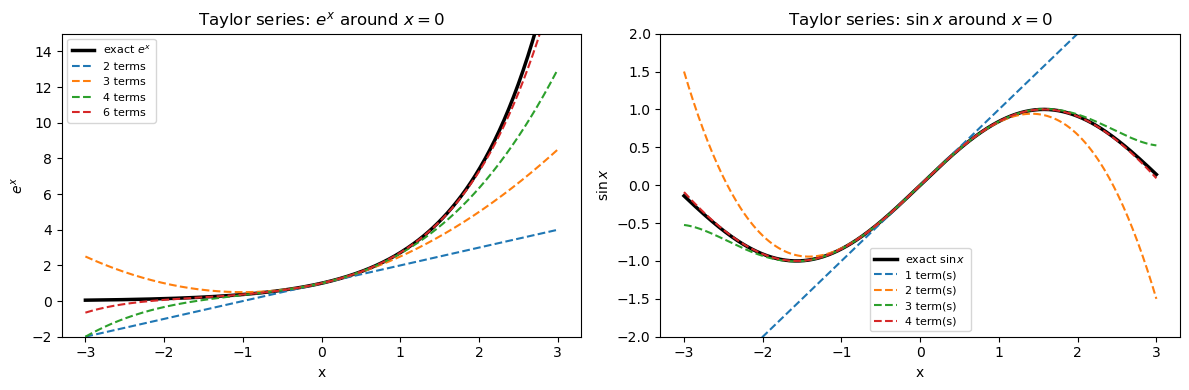

In [32]:
# ── Taylor partial sums: exp(x) and sin(x) ──────────────────────────────────
x = np.linspace(-3, 3, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# -- exp(x) --
ax = axes[0]
ax.plot(x, np.exp(x), 'k-', linewidth=2.5, label='exact $e^x$')
approx = np.zeros_like(x)
for n in range(7):
    approx = approx + x**n / factorial(n)
    if n in [1, 2, 3, 5]:
        ax.plot(x, approx, linestyle='--', linewidth=1.5, label=f'{n+1} terms')
ax.set_ylim(-2, 15)
ax.set_xlabel('x')
ax.set_ylabel(r'$e^x$')
ax.set_title(r'Taylor series: $e^x$ around $x=0$')
ax.legend(fontsize=8)

# -- sin(x) --
ax = axes[1]
ax.plot(x, np.sin(x), 'k-', linewidth=2.5, label=r'exact $\sin x$')
approx = np.zeros_like(x)
for k in range(5):
    n      = 2*k + 1
    sign   = (-1)**k
    approx = approx + sign * x**n / factorial(n)
    if k in [0, 1, 2, 3]:
        ax.plot(x, approx, linestyle='--', linewidth=1.5, label=f'{k+1} term(s)')
ax.set_ylim(-2, 2)
ax.set_xlabel('x')
ax.set_ylabel(r'$\sin x$')
ax.set_title(r'Taylor series: $\sin x$ around $x=0$')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [33]:
# ── Numerical convergence: error vs number of terms for exp(1) ───────────────
exact = np.e
print(f"Exact e = {exact:.10f}\n")
print(f"{'N terms':>8}  {'Approximation':>16}  {'Abs Error':>12}")
print("-" * 42)

approx = 0.0
for n in range(10):
    approx += 1.0**n / factorial(n)
    print(f"{n+1:>8}  {approx:>16.10f}  {abs(approx - exact):>12.2e}")

Exact e = 2.7182818285

 N terms     Approximation     Abs Error
------------------------------------------
       1      1.0000000000      1.72e+00
       2      2.0000000000      7.18e-01
       3      2.5000000000      2.18e-01
       4      2.6666666667      5.16e-02
       5      2.7083333333      9.95e-03
       6      2.7166666667      1.62e-03
       7      2.7180555556      2.26e-04
       8      2.7182539683      2.79e-05
       9      2.7182787698      3.06e-06
      10      2.7182815256      3.03e-07


(12.4.2)=
### 12.4.2 ChE Application: Linearizing the Arrhenius Equation

The Arrhenius rate constant is nonlinear in temperature:

$$
k(T) = A \exp\!\left(-\frac{E_a}{RT}\right)
$$

Applying a first-order Taylor expansion around a reference temperature $T_0$:

$$
k(T) \approx k(T_0) + k'(T_0)\,(T - T_0),
\qquad k'(T_0) = k(T_0) \cdot \frac{E_a}{R T_0^2}
$$

This **linearization** is widely used in reactor stability analysis and temperature control design. It is accurate for small deviations $|T - T_0|$ but degrades further from $T_0$.

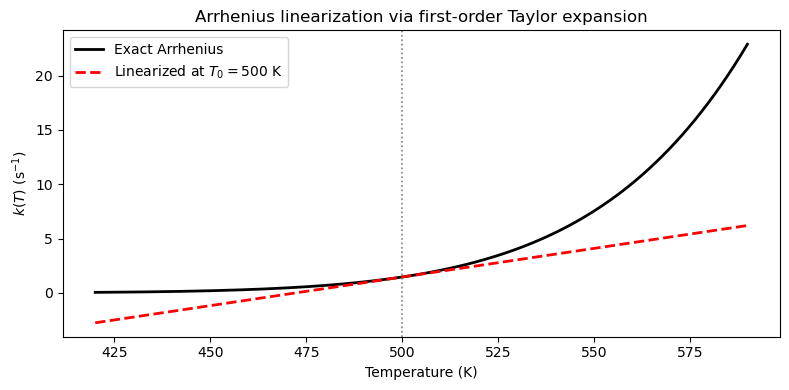

 Delta_T (K)       Exact k      Linear k     Error %
----------------------------------------------------
         -50        0.1967       -1.1746      696.99
         -20        0.6887        0.4065       40.98
         -10        1.0107        0.9335        7.63
          +0        1.4606        1.4606        0.00
         +10        2.0805        1.9876        4.46
         +20        2.9234        2.5146       13.98
         +50        7.5307        4.0957       45.61


In [34]:
# ── Arrhenius linearization around T0 ────────────────────────────────────────
R   = 8.314         # J/(mol K)
Ea  = 75_000.0      # J/mol  (activation energy)
A_f = 1e8           # pre-exponential factor (s^-1)
T0  = 500.0         # K  (linearization reference)

k_exact = lambda T: A_f * np.exp(-Ea / (R * T))

k0     = k_exact(T0)
dk_dT0 = k0 * Ea / (R * T0**2)           # dk/dT evaluated at T0
k_lin  = lambda T: k0 + dk_dT0 * (T - T0)

T_arr = np.linspace(420, 590, 300)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(T_arr, k_exact(T_arr), 'k-',  linewidth=2, label='Exact Arrhenius')
ax.plot(T_arr, k_lin(T_arr),   'r--', linewidth=2,
        label=f'Linearized at $T_0 = {T0:.0f}$ K')
ax.axvline(T0, color='gray', linestyle=':', linewidth=1.2)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel(r'$k(T)$ (s$^{-1}$)')
ax.set_title('Arrhenius linearization via first-order Taylor expansion')
ax.legend()
plt.tight_layout()
plt.show()

# Quantify error at several deviations from T0
print(f"{'Delta_T (K)':>12}  {'Exact k':>12}  {'Linear k':>12}  {'Error %':>10}")
print("-" * 52)
for dT in [-50, -20, -10, 0, 10, 20, 50]:
    T_val = T0 + dT
    err   = 100.0 * abs(k_exact(T_val) - k_lin(T_val)) / k_exact(T_val)
    print(f"{dT:>+12.0f}  {k_exact(T_val):>12.4f}  {k_lin(T_val):>12.4f}  {err:>10.2f}")

(12.5)=
## 12.5 Polynomial Interpolation

**Interpolation** constructs a curve that passes *exactly* through all given data points. With $n+1$ distinct points, there is a unique polynomial of degree $\leq n$ that interpolates them.

The **Lagrange form** writes this polynomial explicitly:

$$
p(x) = \sum_{i=0}^{n} y_i \, L_i(x),
\qquad
L_i(x) = \prod_{\substack{j=0 \\ j \neq i}}^{n} \frac{x - x_j}{x_i - x_j}
$$

Each basis polynomial $L_i$ equals 1 at $x_i$ and 0 at every other node.

(12.5.1)=
### 12.5.1 Lagrange Interpolation from Scratch

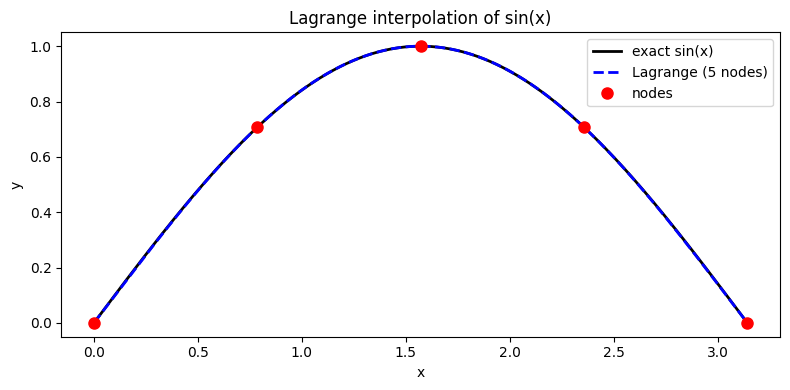

Max interpolation error: 1.81e-03


In [14]:
def lagrange_interp(x_nodes, y_nodes, x_eval):
    """Evaluate the Lagrange interpolating polynomial at x_eval.

    Parameters
    ----------
    x_nodes : array-like  interpolation nodes
    y_nodes : array-like  function values at nodes
    x_eval  : array-like  points at which to evaluate

    Returns
    -------
    p : ndarray   polynomial values at x_eval
    """
    x_nodes = np.asarray(x_nodes, dtype=float)
    y_nodes = np.asarray(y_nodes, dtype=float)
    x_eval  = np.asarray(x_eval,  dtype=float)
    n = len(x_nodes)
    p = np.zeros_like(x_eval)
    for i in range(n):
        L_i = np.ones_like(x_eval)
        for j in range(n):
            if j != i:
                L_i *= (x_eval - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
        p += y_nodes[i] * L_i
    return p


# Test: interpolate sin(x) at 5 equally spaced nodes on [0, pi]
x_nodes = np.linspace(0, np.pi, 5)
y_nodes = np.sin(x_nodes)
x_fine  = np.linspace(0, np.pi, 300)
y_lag   = lagrange_interp(x_nodes, y_nodes, x_fine)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_fine, np.sin(x_fine), 'k-',  linewidth=2, label='exact sin(x)')
ax.plot(x_fine, y_lag,          'b--', linewidth=2, label='Lagrange (5 nodes)')
ax.plot(x_nodes, y_nodes, 'ro', markersize=8, zorder=5, label='nodes')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Lagrange interpolation of sin(x)')
ax.legend()
plt.tight_layout()
plt.show()

max_err = np.max(np.abs(np.sin(x_fine) - y_lag))
print(f"Max interpolation error: {max_err:.2e}")

SciPy also provides `scipy.interpolate.lagrange`, which constructs a `poly1d` object directly:

In [15]:
# ── scipy.interpolate.lagrange ────────────────────────────────────────────────
p_lag = lagrange(x_nodes, y_nodes)   # returns a poly1d object
print("Lagrange polynomial (scipy):")
print(p_lag)

x_test = np.pi / 4
print(f"\np(pi/4)   = {p_lag(x_test):.8f}")
print(f"sin(pi/4) = {np.sin(x_test):.8f}")
print(f"Error     = {abs(p_lag(x_test) - np.sin(x_test)):.2e}")

Lagrange polynomial (scipy):
         4          3           2
0.03758 x - 0.2361 x + 0.05829 x + 0.982 x

p(pi/4)   = 0.70710678
sin(pi/4) = 0.70710678
Error     = 7.77e-16


(12.5.2)=
### 12.5.2 Runge's Phenomenon

High-degree polynomial interpolation on **equally spaced nodes** can produce wild oscillations near the edges of the interval — even though the interpolated function itself is smooth. This is called **Runge's phenomenon**.

The classic example is:

$$
f(x) = \frac{1}{1 + 25x^2}, \qquad x \in [-1, 1]
$$

As the number of equally spaced nodes increases, the interpolating polynomial diverges at the edges of the interval.

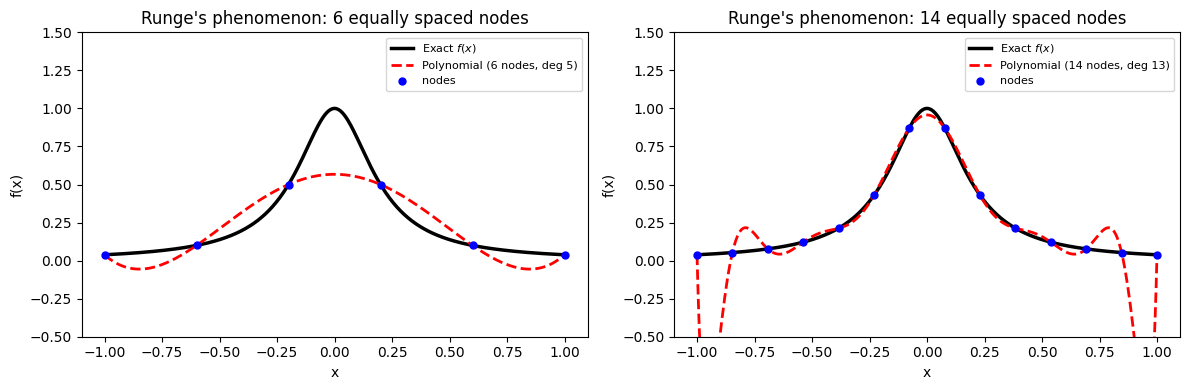

Oscillations grow as n increases — this is Runge's phenomenon.
Fix: use piecewise splines instead of a single high-degree polynomial.


In [16]:
# ── Runge's phenomenon ────────────────────────────────────────────────────────
runge  = lambda x: 1.0 / (1.0 + 25.0 * x**2)
x_fine = np.linspace(-1, 1, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, n_nodes in zip(axes, [6, 14]):
    x_nodes  = np.linspace(-1, 1, n_nodes)
    y_nodes  = runge(x_nodes)
    y_interp = lagrange_interp(x_nodes, y_nodes, x_fine)

    ax.plot(x_fine, runge(x_fine), 'k-',  linewidth=2.5, label='Exact $f(x)$')
    ax.plot(x_fine, y_interp,      'r--', linewidth=2,
            label=f'Polynomial ({n_nodes} nodes, deg {n_nodes-1})')
    ax.plot(x_nodes, y_nodes, 'bo', markersize=5, zorder=5, label='nodes')
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_title(f"Runge's phenomenon: {n_nodes} equally spaced nodes")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Oscillations grow as n increases — this is Runge's phenomenon.")
print("Fix: use piecewise splines instead of a single high-degree polynomial.")

(12.6)=
## 12.6 Spline Interpolation

A **spline** divides the data into intervals and fits a low-degree polynomial on each sub-interval, joining them smoothly at the **knots** (the data points).

A **cubic spline** uses degree-3 polynomials on each interval and enforces:
- The curve passes exactly through every data point
- $p$, $p'$, and $p''$ are continuous at every interior knot

This avoids Runge's phenomenon and produces physically smooth, accurate curves.

| Tool | Description |
|------|-------------|
| `CubicSpline(x, y)` | Natural/not-a-knot cubic spline; supports derivative evaluation |
| `interp1d(x, y, kind='linear')` | Piecewise linear |
| `interp1d(x, y, kind='cubic')` | Piecewise cubic (convenient but less flexible than CubicSpline) |

(12.6.1)=
### 12.6.1 Spline vs Polynomial on the Runge Example

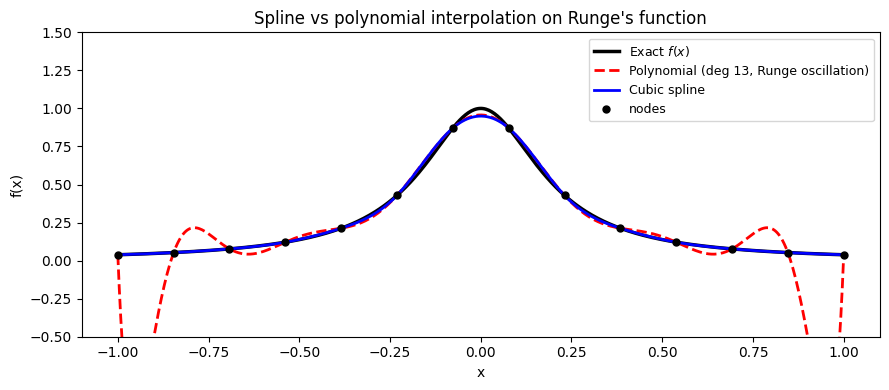

Max error — polynomial : 1.0701
Max error — spline     : 0.0504


In [17]:
# ── Cubic spline vs high-degree polynomial on Runge's function ────────────────
n_nodes = 14
x_nodes = np.linspace(-1, 1, n_nodes)
y_nodes = runge(x_nodes)
x_fine  = np.linspace(-1, 1, 500)

# High-degree polynomial
y_poly   = lagrange_interp(x_nodes, y_nodes, x_fine)

# Cubic spline
cs       = CubicSpline(x_nodes, y_nodes)
y_spline = cs(x_fine)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x_fine, runge(x_fine), 'k-',  linewidth=2.5, label='Exact $f(x)$')
ax.plot(x_fine, y_poly,        'r--', linewidth=2,
        label=f'Polynomial (deg {n_nodes-1}, Runge oscillation)')
ax.plot(x_fine, y_spline,      'b-',  linewidth=2,   label='Cubic spline')
ax.plot(x_nodes, y_nodes, 'ko', markersize=5, zorder=5, label='nodes')
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title("Spline vs polynomial interpolation on Runge's function")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

err_poly   = np.max(np.abs(runge(x_fine) - y_poly))
err_spline = np.max(np.abs(runge(x_fine) - y_spline))
print(f"Max error — polynomial : {err_poly:.4f}")
print(f"Max error — spline     : {err_spline:.4f}")

(12.6.2)=
### 12.6.2 `interp1d`: Linear and Cubic Interpolation

`scipy.interpolate.interp1d` is a convenient general-purpose wrapper. The `kind` argument selects the order: `'linear'`, `'quadratic'`, or `'cubic'`.

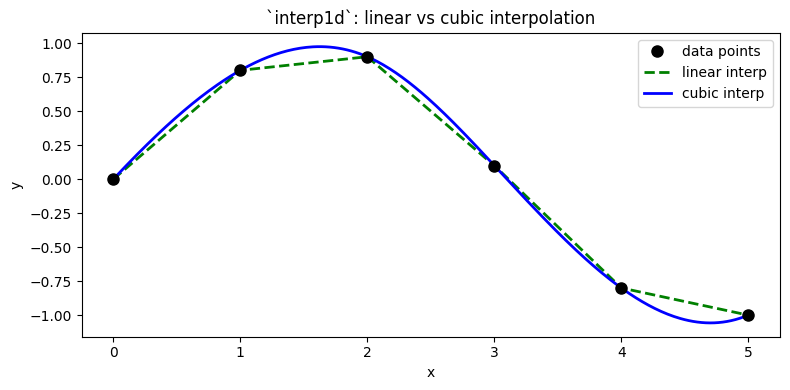

In [18]:
# ── interp1d: linear vs cubic on a small synthetic dataset ───────────────────
x_pts = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0])
y_pts = np.array([0.0, 0.8, 0.9, 0.1, -0.8, -1.0])

x_fine = np.linspace(0, 5, 300)

f_lin = interp1d(x_pts, y_pts, kind='linear')
f_cub = interp1d(x_pts, y_pts, kind='cubic')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_pts,  y_pts,          'ko', markersize=8, zorder=5, label='data points')
ax.plot(x_fine, f_lin(x_fine),  'g--', linewidth=2, label='linear interp')
ax.plot(x_fine, f_cub(x_fine),  'b-',  linewidth=2, label='cubic interp')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('`interp1d`: linear vs cubic interpolation')
ax.legend()
plt.tight_layout()
plt.show()

(12.6.3)=
### 12.6.3 ChE Application: Interpolating Steam Table Data

Steam tables give the enthalpy of vaporization $H_{\rm vap}$ at discrete temperatures. For heat exchanger design we need $H_{\rm vap}$ at arbitrary intermediate conditions.

Below is a hardcoded excerpt from saturated-water steam tables (Smith, Van Ness & Abbott):

| $T$ (°C) | $P_{\rm sat}$ (kPa) | $H_{\rm vap}$ (kJ/kg) |
|----------|---------------------|-----------------------|
| 50       | 12.35               | 2382.7                |
| 75       | 38.58               | 2321.4                |
| 100      | 101.3               | 2256.9                |
| 125      | 232.1               | 2188.5                |
| 150      | 476.2               | 2113.7                |
| 175      | 892.5               | 2031.1                |
| 200      | 1554.0              | 1939.8                |
| 225      | 2550.0              | 1837.8                |
| 250      | 3976.0              | 1715.7                |

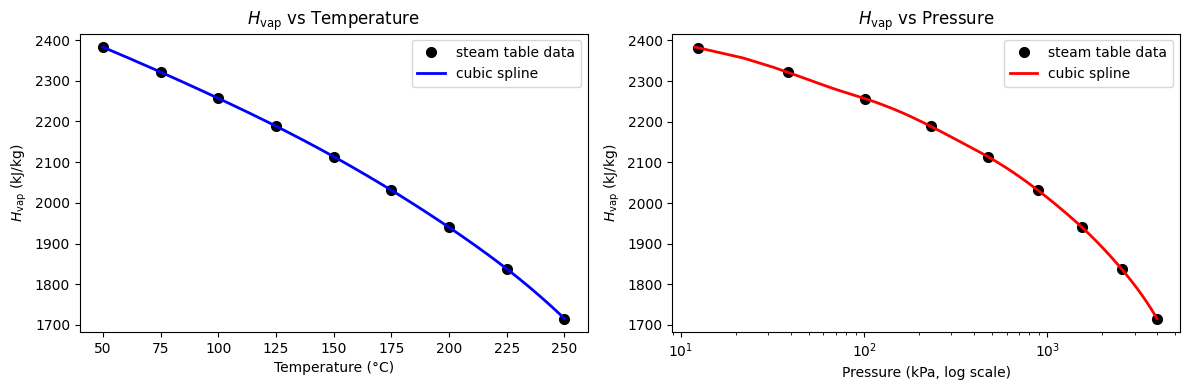

Interpolated H_vap at T = 160 °C : 2081.66 kJ/kg
Interpolated H_vap at P = 620 kPa : 2082.03 kJ/kg


In [19]:
# ── Steam table data ─────────────────────────────────────────────────────────
T_steam = np.array([ 50,   75,   100,   125,   150,
                    175,  200,   225,   250], dtype=float)         # °C
P_sat   = np.array([ 12.35, 38.58, 101.3, 232.1, 476.2,
                    892.5, 1554.0, 2550.0, 3976.0])                 # kPa
Hvap    = np.array([2382.7, 2321.4, 2256.9, 2188.5, 2113.7,
                    2031.1, 1939.8, 1837.8, 1715.7])                # kJ/kg

# ── Build cubic splines ───────────────────────────────────────────────────────
cs_T = CubicSpline(T_steam, Hvap)   # Hvap(T)
cs_P = CubicSpline(P_sat,   Hvap)   # Hvap(P)

T_fine = np.linspace(50, 250, 400)
P_fine = np.linspace(12, 3976, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Hvap vs T
ax = axes[0]
ax.plot(T_steam, Hvap, 'ko', markersize=7, label='steam table data')
ax.plot(T_fine, cs_T(T_fine), 'b-', linewidth=2, label='cubic spline')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel(r'$H_{\rm vap}$ (kJ/kg)')
ax.set_title(r'$H_{\rm vap}$ vs Temperature')
ax.legend()

# Hvap vs P (log scale)
ax = axes[1]
ax.semilogx(P_sat,   Hvap,          'ko', markersize=7, label='steam table data')
ax.semilogx(P_fine,  cs_P(P_fine),  'r-', linewidth=2,  label='cubic spline')
ax.set_xlabel('Pressure (kPa, log scale)')
ax.set_ylabel(r'$H_{\rm vap}$ (kJ/kg)')
ax.set_title(r'$H_{\rm vap}$ vs Pressure')
ax.legend()

plt.tight_layout()
plt.show()

# Spot-check: interpolate at intermediate conditions
T_q = 160.0    # °C
P_q = 620.0    # kPa
print(f"Interpolated H_vap at T = {T_q:.0f} °C : {cs_T(T_q):.2f} kJ/kg")
print(f"Interpolated H_vap at P = {P_q:.0f} kPa : {cs_P(P_q):.2f} kJ/kg")

In [20]:
# ── Compare linear vs cubic interpolation on steam table ─────────────────────
f_lin_steam = interp1d(T_steam, Hvap, kind='linear')
f_cub_steam = interp1d(T_steam, Hvap, kind='cubic')

T_test = np.array([85.0, 110.0, 140.0, 190.0, 230.0])

print(f"{'T (C)':>7}  {'Linear (kJ/kg)':>16}  {'Cubic (kJ/kg)':>15}  {'Diff (kJ/kg)':>14}")
print("-" * 60)
for T_val in T_test:
    h_lin = float(f_lin_steam(T_val))
    h_cub = float(f_cub_steam(T_val))
    print(f"{T_val:>7.0f}  {h_lin:>16.2f}  {h_cub:>15.2f}  {h_cub - h_lin:>14.3f}")

print("\nCubic interpolation follows the curvature better — preferred for accurate engineering work.")

  T (C)    Linear (kJ/kg)    Cubic (kJ/kg)    Diff (kJ/kg)
------------------------------------------------------------
     85           2295.60          2295.99           0.392
    110           2229.54          2230.14           0.596
    140           2143.62          2144.50           0.879
    190           1976.32          1977.38           1.062
    230           1813.38          1815.35           1.970

Cubic interpolation follows the curvature better — preferred for accurate engineering work.


(12.7)=
## 12.7 Summary

| Concept | Tool / Formula | When to use |
|---------|---------------|-------------|
| **Polynomial evaluation** | `np.polyval(coeffs, x)` | Evaluate a stored coefficient array at $x$ |
| **Polynomial object** | `np.poly1d(coeffs)` | Callable; `.integ()` returns antiderivative |
| **Least-squares fit** | `np.polyfit(x, y, deg)` | Fit noisy or tabulated data; keep degree small |
| **Residuals** | $e_i = y_i - p(x_i)$ | Signed error at each data point |
| **MAE** | $\frac{1}{N}\sum\|e_i\|$ | Average error in original units; easy to interpret |
| **MSE** | $\frac{1}{N}\sum e_i^2$ | Penalizes large errors; units are $y^2$ |
| **$R^2$** | $1 - \sum e_i^2 / \sum(y_i-\bar{y})^2$ | Fraction of variance explained; 1 = perfect |
| **Taylor series** | $\sum f^{(n)}(a)/n! \cdot (x-a)^n$ | Approximate nonlinear functions locally |
| **Linearization** | First-order Taylor around $T_0$ | Reactor stability, control design |
| **Lagrange interp** | `scipy.interpolate.lagrange` | Exact through data; avoid for large $n$ |
| **Runge's phenomenon** | Oscillation with high-degree, equally spaced nodes | Signal to switch to splines |
| **Cubic spline** | `CubicSpline(x, y)` | Smooth interpolation of tables; preferred |
| **Piecewise interp** | `interp1d(x, y, kind=...)` | Quick linear or cubic; good for data look-ups |

**Rule of thumb for ChE data:**
- Use `np.polyfit` with degree 2–4 for smooth physical properties ($C_p$, $\mu$, $k$)
- Use `CubicSpline` when you need to interpolate a table and preserve curvature
- Never use a single high-degree polynomial for interpolation — use splines instead
- Always plot the fit and report MAE/$R^2$ before trusting any model